# Project 1 — How many stubborns are too many?

In [6]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(suppress=True)
plt.rcParams["figure.dpi"] = 110

### 1.Defining formulas

In [7]:
state_delta = [
    ( 0, -1,  1),  # r1  X+Y  -> X+U      (X inhibits Y)
    (-1,  0,  1),  # r2  X+Y  -> U+Y      (Y inhibits X)
    ( 1,  0, -1),  # r3  X+U  -> 2X       (X recruits U)
    ( 0,  1, -1),  # r4  Y+U  -> 2Y       (Y recruits U)
    (-1,  0,  1),  # r5  X+ZY -> U+ZY     (zealot-Y inhibits X)
    ( 0,  1, -1),  # r6  U+ZY -> Y+ZY     (zealot-Y recruits U)
    ( 0, -1,  1),  # r7  Y+ZX -> U+ZX     (zealot-X inhibits Y)
    ( 1,  0, -1),  # r8  U+ZX -> X+ZX     (zealot-X recruits U)
]


def cross_inhibition_rates(x, y, u, Zx, Zy, qx, qy):
    return (
        qx * x * y,
        qy * x * y,
        qx * x * u,
        qy * y * u,
        qy * x * Zy,
        qy * u * Zy,
        qx * y * Zx,
        qx * u * Zx,
    )


def sample_reaction(rates, rate_total, rng):
    pick = rng.uniform(0.0, rate_total)
    acc = 0.0
    for i, r in enumerate(rates):
        acc += r
        if pick <= acc:
            return i
    return len(rates) - 1


def fill_grid_until(t_grid, grid_idx, t_stop, state, arrays):
    while grid_idx < len(t_grid) and t_grid[grid_idx] <= t_stop:
        for name, arr in arrays.items():
            arr[grid_idx] = state[name]
        grid_idx += 1
    return grid_idx


def simulate_trace(N, Zx, Zy, Qx, Qy, x0, y0, u0, T, t_grid, rng):
    """Full Gillespie SSA trajectory on a fixed time grid (for plotting). `rng` is a
    stdlib random.Random instance."""
    qx, qy = Qx / N, Qy / N
    x, y, u = int(x0), int(y0), int(u0)
    t = 0.0

    x_grid = np.empty_like(t_grid, dtype=float)
    y_grid = np.empty_like(t_grid, dtype=float)
    u_grid = np.empty_like(t_grid, dtype=float)
    state = {"x": x, "y": y, "u": u}
    arrays = {"x": x_grid, "y": y_grid, "u": u_grid}

    grid_idx = fill_grid_until(t_grid, 0, t, state, arrays)

    while t < T:
        rates = cross_inhibition_rates(x, y, u, Zx, Zy, qx, qy)
        rate_total = sum(rates)
        if rate_total <= 0:
            break
        dt = rng.expovariate(rate_total)
        t_next = t + dt
        grid_idx = fill_grid_until(t_grid, grid_idx, min(t_next, T), state, arrays)
        if t_next > T:
            break
        reaction = sample_reaction(rates, rate_total, rng)
        dx, dy, du = state_delta[reaction]
        x += dx; y += dy; u += du
        state = {"x": x, "y": y, "u": u}
        t = t_next

    fill_grid_until(t_grid, grid_idx, T, state, arrays)
    return {"x": x_grid, "y": y_grid, "u": u_grid}

### 2. Reproducing Fig. 2: 

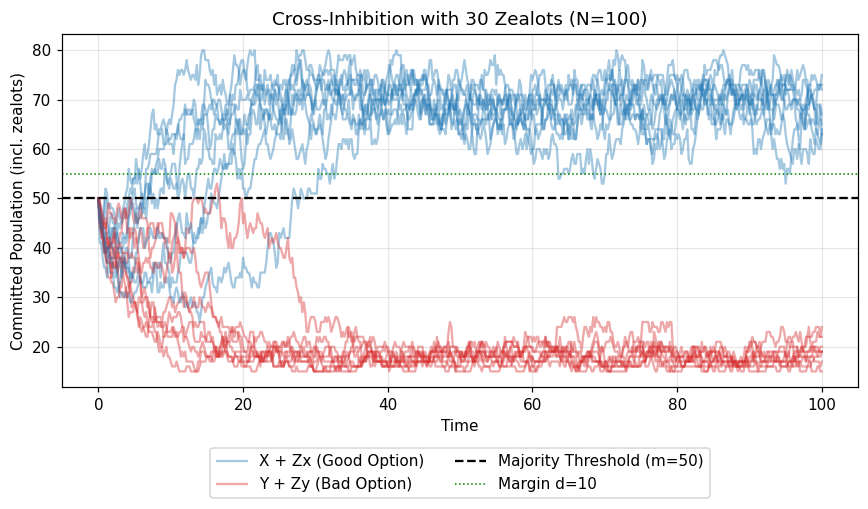

In [20]:
N_demo = 100
Zx_demo = Zy_demo = 15   
Qx_demo, Qy_demo = 1.05, 0.95
x0_demo = N_demo // 2 - Zx_demo
y0_demo = N_demo // 2 - Zy_demo
T_demo = 100.0
t_grid_demo = np.linspace(0, T_demo, 501)

rng = random.Random(7)
n_example_traces = 8
traces = [
    simulate_trace(N_demo, Zx_demo, Zy_demo, Qx_demo, Qy_demo,
                    x0_demo, y0_demo, 0, T_demo, t_grid_demo, rng)
    for _ in range(n_example_traces)
]

fig, ax = plt.subplots(figsize=(8, 4.8))

for i, tr in enumerate(traces):
    label_x = "X + Zx (Good Option)" if i == 0 else None
    label_y = "Y + Zy (Bad Option)" if i == 0 else None
    
    # Plotted X as blue, Y as red
    ax.plot(t_grid_demo, tr["x"] + Zx_demo, color="tab:blue", alpha=0.4, label=label_x)
    ax.plot(t_grid_demo, tr["y"] + Zy_demo, color="tab:red", alpha=0.4, label=label_y)

ax.axhline(N_demo / 2, linestyle="--", linewidth=1.5, color="black", label="Majority Threshold (m=50)")
ax.axhline((N_demo / 2) + 5, linestyle=":", linewidth=1, color="green", label="Margin d=10")
ax.set_xlabel("Time")
ax.set_ylabel("Committed Population (incl. zealots)")
ax.set_title(f"Cross-Inhibition with 30 Zealots (N={N_demo})")
ax.legend(
    loc="upper center", 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=2
) 
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.show()

### 3. Consensus as a BLTL property.

In [ ]:
def check_consensus(N, Zx, Zy, Qx, Qy, x0, y0, u0, m_pct, d, t_reach, h_hold, T, rng):
    """One SSA run of the BLTL good/bad consensus property.

    Returns (good_reached_and_held, bad_reached_and_held).
    """
    qx, qy = Qx / N, Qy / N
    minm = (m_pct / 100.0) * N
    x, y, u = int(x0), int(y0), int(u0)
    t = 0.0
    good_since = None
    bad_since = None

    def evaluate(x, y):
        good = (x + Zx >= minm) and ((x + Zx) - (y + Zy) >= d)
        bad = (y + Zy >= minm) and ((y + Zy) - (x + Zx) >= d)
        return good, bad

    while t < T:
        rates = cross_inhibition_rates(x, y, u, Zx, Zy, qx, qy)
        rate_total = sum(rates)
        if rate_total <= 0:
            break
        dt = rng.expovariate(rate_total)
        t_next = t + dt
        if t_next >= T:
            t = T
        else:
            reaction = sample_reaction(rates, rate_total, rng)
            dx, dy, du = state_delta[reaction]
            x += dx; y += dy; u += du
            t = t_next

        good, bad = evaluate(x, y)

        if t <= t_reach:
            good_since = t if (good and good_since is None) else (good_since if good else None)
            bad_since = t if (bad and bad_since is None) else (bad_since if bad else None)
        else:
            if not good:
                good_since = None
            if not bad:
                bad_since = None

        if good_since is not None and (t - good_since) >= h_hold:
            return True, False
        if bad_since is not None and (t - bad_since) >= h_hold:
            return False, True

    return False, False


def consensus_probabilities(N, z_pct, Qx, Qy, trials, m_pct=50, t_reach=35.0, h_hold=40.0,
                             T=None, seed=0):
    """Estimate P(good consensus) and P(bad consensus) for a given total zealot percentage."""
    Zx = Zy = int(round((z_pct / 100.0) * N / 2))
    x0 = N // 2 - Zx
    y0 = N // 2 - Zy
    d = max(1, round(0.1 * N))
    if T is None:
        T = t_reach + h_hold + 45.0
    rng = random.Random(int(seed)) 
    good = bad = 0
    for _ in range(trials):
        g, b = check_consensus(N, Zx, Zy, Qx, Qy, x0, y0, 0, m_pct, d, t_reach, h_hold, T, rng)
        good += g
        bad += b
    return good / trials, bad / trials

### 4. Reproducing Fig. 3(c): consensus probability vs. zealot fraction at N=100.

Fig. 3(c) reproduction: 26 points x 300 trials in 25.5s


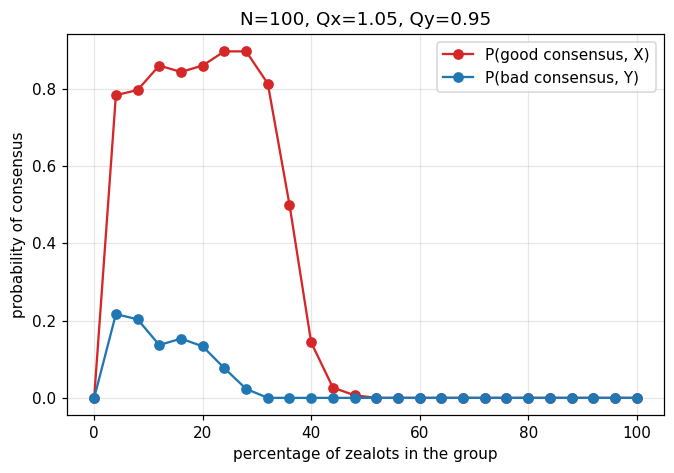

,z_pct,P_good,P_bad
0,0,0.000000,0.000000
1,4,0.783333,0.216667
2,8,0.796667,0.203333
3,12,0.860000,0.136667
4,16,0.843333,0.153333
5,20,0.860000,0.133333
6,24,0.896667,0.076667
7,28,0.896667,0.023333
8,32,0.813333,0.000000
9,36,0.500000,0.000000


In [ ]:
z_grid = np.arange(0, 101, 4)   #varying percentage of zealots
trials_fig3 = 300
Qx_headline, Qy_headline = 1.05, 0.95

start = time.perf_counter()
rows = []
for z in z_grid:
    pg, pb = consensus_probabilities(100, z, Qx_headline, Qy_headline, trials_fig3, seed=1000 + z)
    rows.append({"z_pct": z, "P_good": pg, "P_bad": pb})
fig3_df = pd.DataFrame(rows)
print(f"Fig. 3(c) reproduction: {len(z_grid)} points x {trials_fig3} trials in {time.perf_counter()-start:.1f}s")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fig3_df.z_pct, fig3_df.P_good, "o-", color="tab:red", label="P(good consensus, X)")
ax.plot(fig3_df.z_pct, fig3_df.P_bad, "o-", color="tab:blue", label="P(bad consensus, Y)")
ax.set_xlabel("percentage of zealots in the group")
ax.set_ylabel("consensus probability")
ax.set_title(f"N=100, Qx={Qx_headline}, Qy={Qy_headline}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
fig3_df

### 5. Focus of this project: scaling with swarm size N.

N-scaling sweep: 5 x 26 points x 300 trials in 359.0s


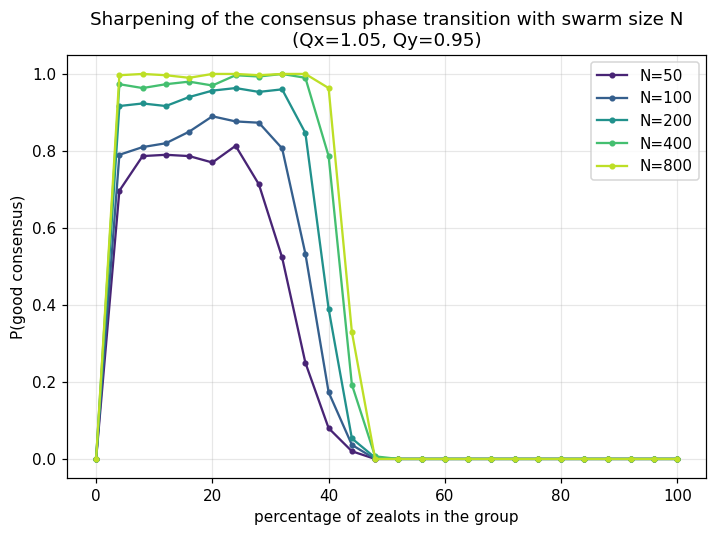

In [11]:
N_values = [50, 100, 200, 400, 800]
z_grid_scaling = np.arange(0, 101, 4)
trials_scaling = 300

start = time.perf_counter()
scaling_rows = []
for N in N_values:
    for z in z_grid_scaling:
        pg, pb = consensus_probabilities(N, z, Qx_headline, Qy_headline, trials_scaling, seed=2000 + N + z)
        scaling_rows.append({"N": N, "z_pct": z, "P_good": pg, "P_bad": pb})
scaling_df = pd.DataFrame(scaling_rows)
print(f"N-scaling sweep: {len(N_values)} x {len(z_grid_scaling)} points x {trials_scaling} trials "
      f"in {time.perf_counter()-start:.1f}s")

fig, ax = plt.subplots(figsize=(7.5, 5))
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(N_values)))
for color, N in zip(cmap, N_values):
    sub = scaling_df[scaling_df.N == N]
    ax.plot(sub.z_pct, sub.P_good, "o-", color=color, label=f"N={N}", markersize=3)
ax.set_xlabel("percentage of zealots in the group")
ax.set_ylabel("P(good consensus)")
ax.set_title(f"Sharpening of the consensus phase transition with swarm size N\n(Qx={Qx_headline}, Qy={Qy_headline})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Quantifying the sharpening.

In [12]:
def crossing(z, p, level):
    """Linear-interpolated z at which p crosses `level` (descending)."""
    for i in range(len(p) - 1):
        if p[i] >= level > p[i + 1]:
            frac = (p[i] - level) / (p[i] - p[i + 1])
            return z[i] + frac * (z[i + 1] - z[i])
    return np.nan


summary_rows = []
for N in N_values:
    sub = scaling_df[scaling_df.N == N].sort_values("z_pct")
    z = sub.z_pct.values
    p = sub.P_good.values
    z90 = crossing(z, p, 0.9)
    z50 = crossing(z, p, 0.5)
    z10 = crossing(z, p, 0.1)
    width = z10 - z90 if not (np.isnan(z10) or np.isnan(z90)) else np.nan
    summary_rows.append({"N": N, "z_90pct": z90, "z_critical_50pct": z50, "z_10pct": z10, "transition_width": width})

scaling_summary = pd.DataFrame(summary_rows)
scaling_summary["width_x_sqrtN"] = scaling_summary.transition_width * np.sqrt(scaling_summary.N)
scaling_summary

,N,z_90pct,z_critical_50pct,z_10pct,transition_width,width_x_sqrtN
0,50,NaN,32.341463,39.529412,NaN,NaN
1,100,NaN,36.370370,42.146341,NaN,NaN
2,200,34.117647,39.036496,43.445545,9.327897,131.916391
3,400,37.770492,41.932584,46.000000,8.229508,164.590164
4,800,40.400000,42.926316,46.787879,6.387879,180.676496


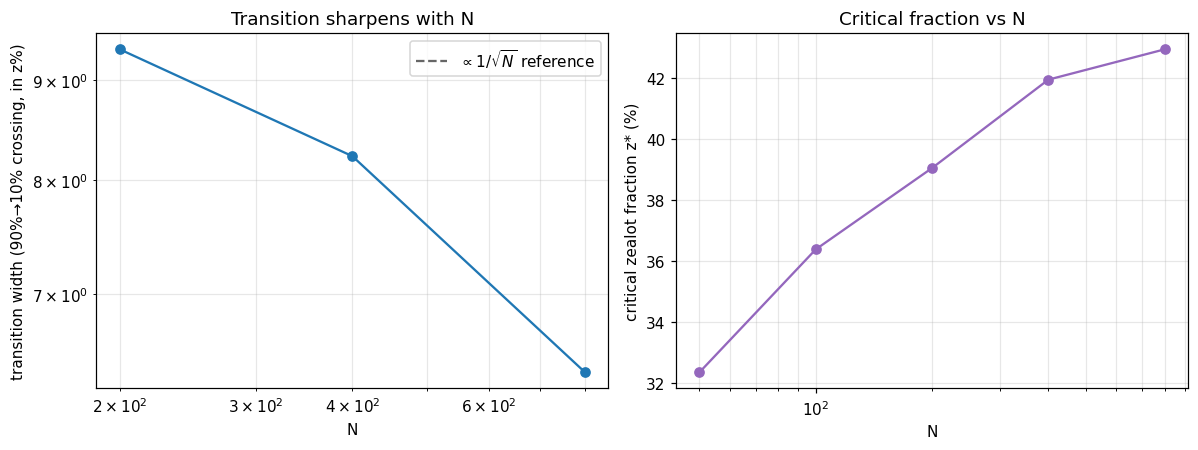

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].loglog(scaling_summary.N, scaling_summary.transition_width, "o-")
ref_N = np.array(N_values, dtype=float)
ref = scaling_summary.transition_width.iloc[0] * np.sqrt(scaling_summary.N.iloc[0]) / np.sqrt(ref_N)
axes[0].loglog(ref_N, ref, "k--", alpha=0.6, label=r"$\propto 1/\sqrt{N}$ reference")
axes[0].set_xlabel("N")
axes[0].set_ylabel("transition width (90%→10% crossing, in z%)")
axes[0].set_title("Transition sharpens with N")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogx(scaling_summary.N, scaling_summary.z_critical_50pct, "o-", color="tab:purple")
axes[1].set_xlabel("N")
axes[1].set_ylabel("critical zealot fraction z* (%)")
axes[1].set_title("Critical fraction vs N")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Analytical explanation: the mean-field (thermodynamic) limit.

In [ ]:
def mean_field_deriv(xi, eta, zeta, Qx, Qy):
    phi = 1 - xi - eta - 2 * zeta
    dxi = Qx * phi * (xi + zeta) - Qy * xi * (eta + zeta)
    deta = Qy * phi * (eta + zeta) - Qx * eta * (xi + zeta)
    return dxi, deta


def rk4_step(xi, eta, zeta, Qx, Qy, dt):
    k1 = mean_field_deriv(xi, eta, zeta, Qx, Qy)
    k2 = mean_field_deriv(xi + dt / 2 * k1[0], eta + dt / 2 * k1[1], zeta, Qx, Qy)
    k3 = mean_field_deriv(xi + dt / 2 * k2[0], eta + dt / 2 * k2[1], zeta, Qx, Qy)
    k4 = mean_field_deriv(xi + dt * k3[0], eta + dt * k3[1], zeta, Qx, Qy)
    xi_new = xi + dt / 6 * (k1[0] + 2 * k2[0] + 2 * k3[0] + k4[0])
    eta_new = eta + dt / 6 * (k1[1] + 2 * k2[1] + 2 * k3[1] + k4[1])
    return xi_new, eta_new


def mean_field_endpoint(zeta, Qx, Qy, T=200.0, dt=0.02):
    xi = eta = (1 - 2 * zeta) / 2
    for _ in range(int(T / dt)):
        xi, eta = rk4_step(xi, eta, zeta, Qx, Qy, dt)
    return xi, eta


def mean_field_good_consensus(zeta, Qx, Qy, m=0.5, d=0.1):
    xi, eta = mean_field_endpoint(zeta, Qx, Qy)
    return (xi + zeta >= m) and ((xi + zeta) - (eta + zeta) >= d)


def find_critical_zeta(Qx, Qy, lo=0.0, hi=0.5, iters=25):
    """Bisection: mean_field_good_consensus(lo)=True, (hi)=False assumed."""
    assert mean_field_good_consensus(lo, Qx, Qy)
    assert not mean_field_good_consensus(hi, Qx, Qy)
    for _ in range(iters):
        mid = (lo + hi) / 2
        if mean_field_good_consensus(mid, Qx, Qy):
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


zeta_star = find_critical_zeta(Qx_headline, Qy_headline)
z_star_pct = 2 * zeta_star * 100
print(f"Mean-field (N->inf) critical total zealot fraction: z* = {z_star_pct:.2f}%")
print("Paper reported value for the same Qx, Qy (cross-inhibition + zealots, N=100 baseline): 48%")

Mean-field (N->inf) critical total zealot fraction: z* = 48.72%
Paper's reported value for the same Qx, Qy (cross-inhibition + zealots, N=100 baseline): 48%


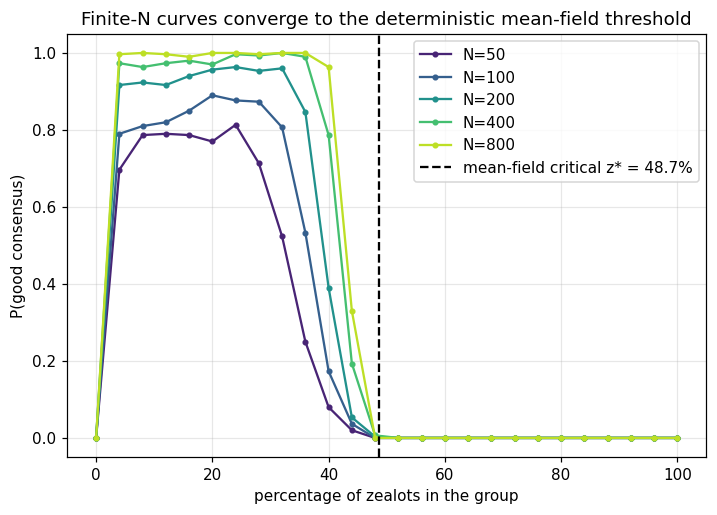

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for color, N in zip(cmap, N_values):
    sub = scaling_df[scaling_df.N == N]
    ax.plot(sub.z_pct, sub.P_good, "o-", color=color, label=f"N={N}", markersize=3)
ax.axvline(z_star_pct, color="black", linestyle="--", linewidth=1.5,
           label=f"mean-field critical z* = {z_star_pct:.1f}%")
ax.set_xlabel("percentage of zealots in the group")
ax.set_ylabel("P(good consensus)")
ax.set_title("Finite-N curves converge to the deterministic mean-field threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()